In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda



In [14]:

img = plt.imread("photo.jpg")
h, w, _ = img.shape
print(img.shape)

(800, 1200, 3)


In [15]:
filt = np.array([
    [0,  0,  1,   2,  1,  0, 0],
    [0,  3, 13,  22, 13,  3, 0],
    [1, 13, 59,  97, 59, 13, 1],
    [2, 22, 97, 159, 97, 22, 2],
    [1, 13, 59,  97, 59, 13, 1],
    [0,  3, 13,  22, 13,  3, 0],
    [0,  0,  1,   2,  1,  0, 0]
], dtype=np.float32)

print(filt.sum())


1003.0


In [16]:
start = time.time()

blurCPU = np.zeros((h, w, 3), np.uint8)
for y in range(h):
    for x in range(w):
        for c in range(3):
            s = 0.0
            wsum = 0.0
            for i in range(7):
                for j in range(7):
                    ny = y + i - 3
                    nx = x + j - 3
                    if ny >= 0 and ny < h and nx >= 0 and nx < w:
                        s += img[ny, nx, c] * filt[i, j]
                        wsum += filt[i, j]
            blurCPU[y, x, c] = int(s / wsum)

cpuTime = time.time() - start
print("CPU time:", cpuTime, "s")


CPU time: 233.28378343582153 s


In [17]:
@cuda.jit
def blur(src, dst, filt):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    h = src.shape[0]
    w = src.shape[1]
    if y < h and x < w:
        for c in range(3):
            s = 0.0
            wsum = 0.0
            for i in range(7):
                for j in range(7):
                    ny = y + i - 3
                    nx = x + j - 3
                    if ny >= 0 and ny < h and nx >= 0 and nx < w:
                        s += src[ny, nx, c] * filt[i, j]
                        wsum += filt[i, j]
            dst[y, x, c] = np.uint8(s / wsum)


In [18]:
@cuda.jit
def blur_shared(src, dst, filt):
    sfilt = cuda.shared.array((7, 7), np.float32)
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    if tx < 7 and ty < 7:
        sfilt[ty, tx] = filt[ty, tx]
    cuda.syncthreads()

    x = tx + cuda.blockIdx.x * cuda.blockDim.x
    y = ty + cuda.blockIdx.y * cuda.blockDim.y
    h = src.shape[0]
    w = src.shape[1]
    if y < h and x < w:
        for c in range(3):
            s = 0.0
            wsum = 0.0
            for i in range(7):
                for j in range(7):
                    ny = y + i - 3
                    nx = x + j - 3
                    if ny >= 0 and ny < h and nx >= 0 and nx < w:
                        s += src[ny, nx, c] * sfilt[i, j]
                        wsum += sfilt[i, j]
            dst[y, x, c] = np.uint8(s / wsum)


In [19]:
devSrc = cuda.to_device(img)
devDst = cuda.device_array((h, w, 3), np.uint8)
devFilt = cuda.to_device(filt)


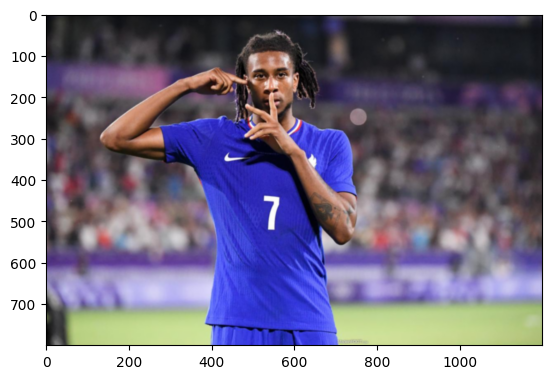

Max diff without shared: 0
Max diff with shared: 0


In [20]:
blockSize = (16, 16)
gridSize = ((w + 15) // 16, (h + 15) // 16)

blur[gridSize, blockSize](devSrc, devDst, devFilt)
cuda.synchronize()
blurGPU = devDst.copy_to_host()

blur_shared[gridSize, blockSize](devSrc, devDst, devFilt)
cuda.synchronize()
blurShared = devDst.copy_to_host()

plt.imshow(blurGPU)
plt.show()
plt.imsave("blur_gpu.png", blurGPU)

print("Max diff without shared:", np.abs(blurGPU.astype(int) - blurCPU.astype(int)).max())
print("Max diff with shared:", np.abs(blurShared.astype(int) - blurCPU.astype(int)).max())


In [21]:
def measure(kernel, grid, block, src, dst, filt):
    kernel[grid, block](src, dst, filt)
    cuda.synchronize()
    start = time.time()
    for r in range(100):
        kernel[grid, block](src, dst, filt)
    cuda.synchronize()
    return (time.time() - start) / 100


8 x 8 | without shared: 0.006822283267974853 s | with shared: 0.0052967071533203125 s
16 x 8 | without shared: 0.005301711559295655 s | with shared: 0.00530501127243042 s
16 x 16 | without shared: 0.0052918529510498045 s | with shared: 0.005293350219726562 s
32 x 16 | without shared: 0.005400955677032471 s | with shared: 0.005403656959533692 s
32 x 32 | without shared: 0.005442757606506348 s | with shared: 0.00544421911239624 s


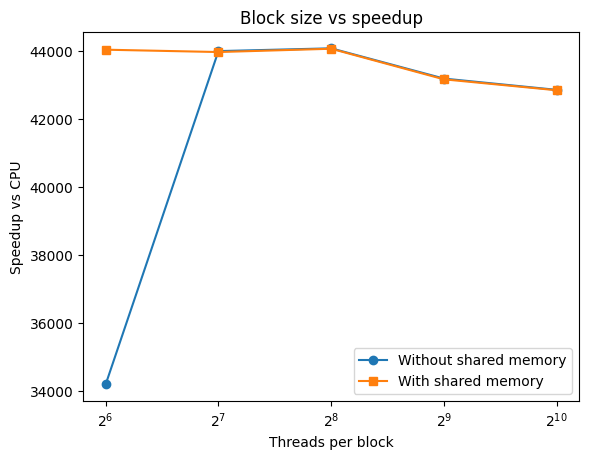

In [22]:
blocks2D = [(8, 8), (16, 8), (16, 16), (32, 16), (32, 32)]
threads = []
speedupNoShared = []
speedupShared = []

for bx, by in blocks2D:
    grid = ((w + bx - 1) // bx, (h + by - 1) // by)
    t1 = measure(blur, grid, (bx, by), devSrc, devDst, devFilt)
    t2 = measure(blur_shared, grid, (bx, by), devSrc, devDst, devFilt)

    threads.append(bx * by)
    speedupNoShared.append(cpuTime / t1)
    speedupShared.append(cpuTime / t2)
    print(bx, "x", by, "| without shared:", t1, "s | with shared:", t2, "s")

plt.plot(threads, speedupNoShared, marker="o", label="Without shared memory")
plt.plot(threads, speedupShared, marker="s", label="With shared memory")
plt.xscale("log", base=2)
plt.xlabel("Threads per block")
plt.ylabel("Speedup vs CPU")
plt.title("Block size vs speedup")
plt.legend()
plt.savefig("blocksize_vs_speedup.png")
plt.show()


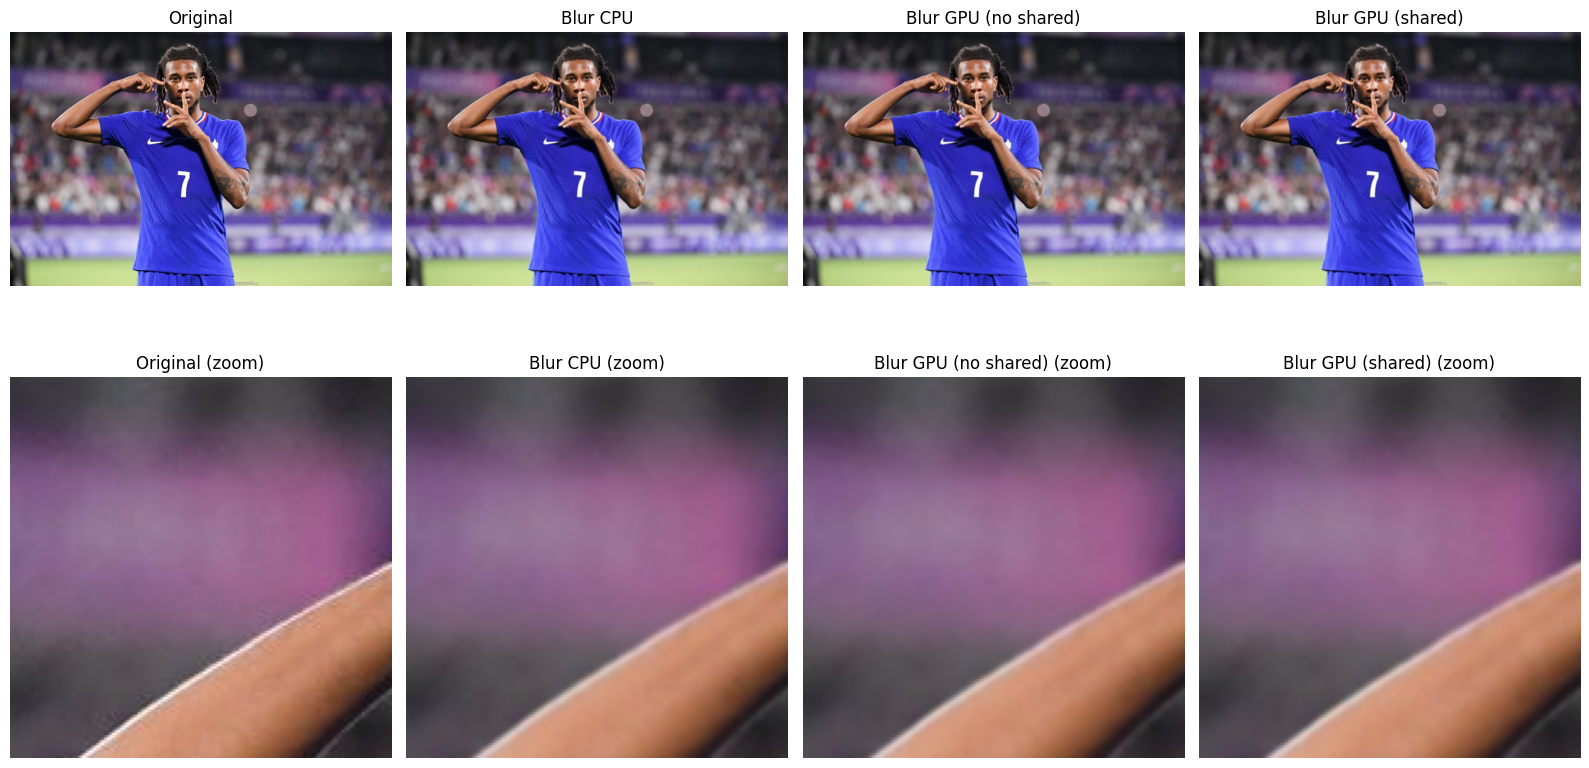

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

images = [img, blurCPU, blurGPU, blurShared]
titles = ["Original", "Blur CPU", "Blur GPU (no shared)", "Blur GPU (shared)"]

for k in range(4):
    axes[0, k].imshow(images[k])
    axes[0, k].set_title(titles[k])
    axes[0, k].axis("off")

    axes[1, k].imshow(images[k][100:250, 150:300])
    axes[1, k].set_title(titles[k] + " (zoom)")
    axes[1, k].axis("off")

plt.tight_layout()
plt.savefig("comparison.png")
plt.show()
